# Linear Regression: OLS vs WLS Prototype
This notebook plots Ordinary Least Squares (OLS) and Weighted Least Squares (WLS) linear regression lines for 13-day and 54-day lookbacks, alongside their respective slopes and price variances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_SHORT = 13
LOOKBACK_LONG = 54
PLOT_START = '2023-01-01'
PLOT_END = '2023-03-31'

WARMUP_DAYS = LOOKBACK_LONG + 10

In [2]:
# --- MATH FUNCTIONS ---
def calc_rolling_regression(series, window, use_wls=False):
    """
    Calculates the regression line value and annualized slope.
    If use_wls=True, applies linearly increasing weights to recent prices.
    """
    reg_line_values = np.full(len(series), np.nan)
    slopes = np.full(len(series), np.nan)
    
    x = np.arange(window)
    # Linear weighting: [1, 2, 3, ... window]
    w = np.arange(1, window + 1) if use_wls else np.ones(window)
    sum_w = np.sum(w)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        
        w_mean_x = np.sum(w * x) / sum_w
        w_mean_y = np.sum(w * y) / sum_w
        
        cov = np.sum(w * (x - w_mean_x) * (y - w_mean_y))
        var_x = np.sum(w * (x - w_mean_x)**2)
        
        slope = cov / var_x
        intercept = w_mean_y - slope * w_mean_x
        
        reg_line_values[i] = (slope * (window - 1)) + intercept
        slopes[i] = (slope / w_mean_y) * 252 * 100
        
    return pd.Series(reg_line_values, index=series.index), pd.Series(slopes, index=series.index)

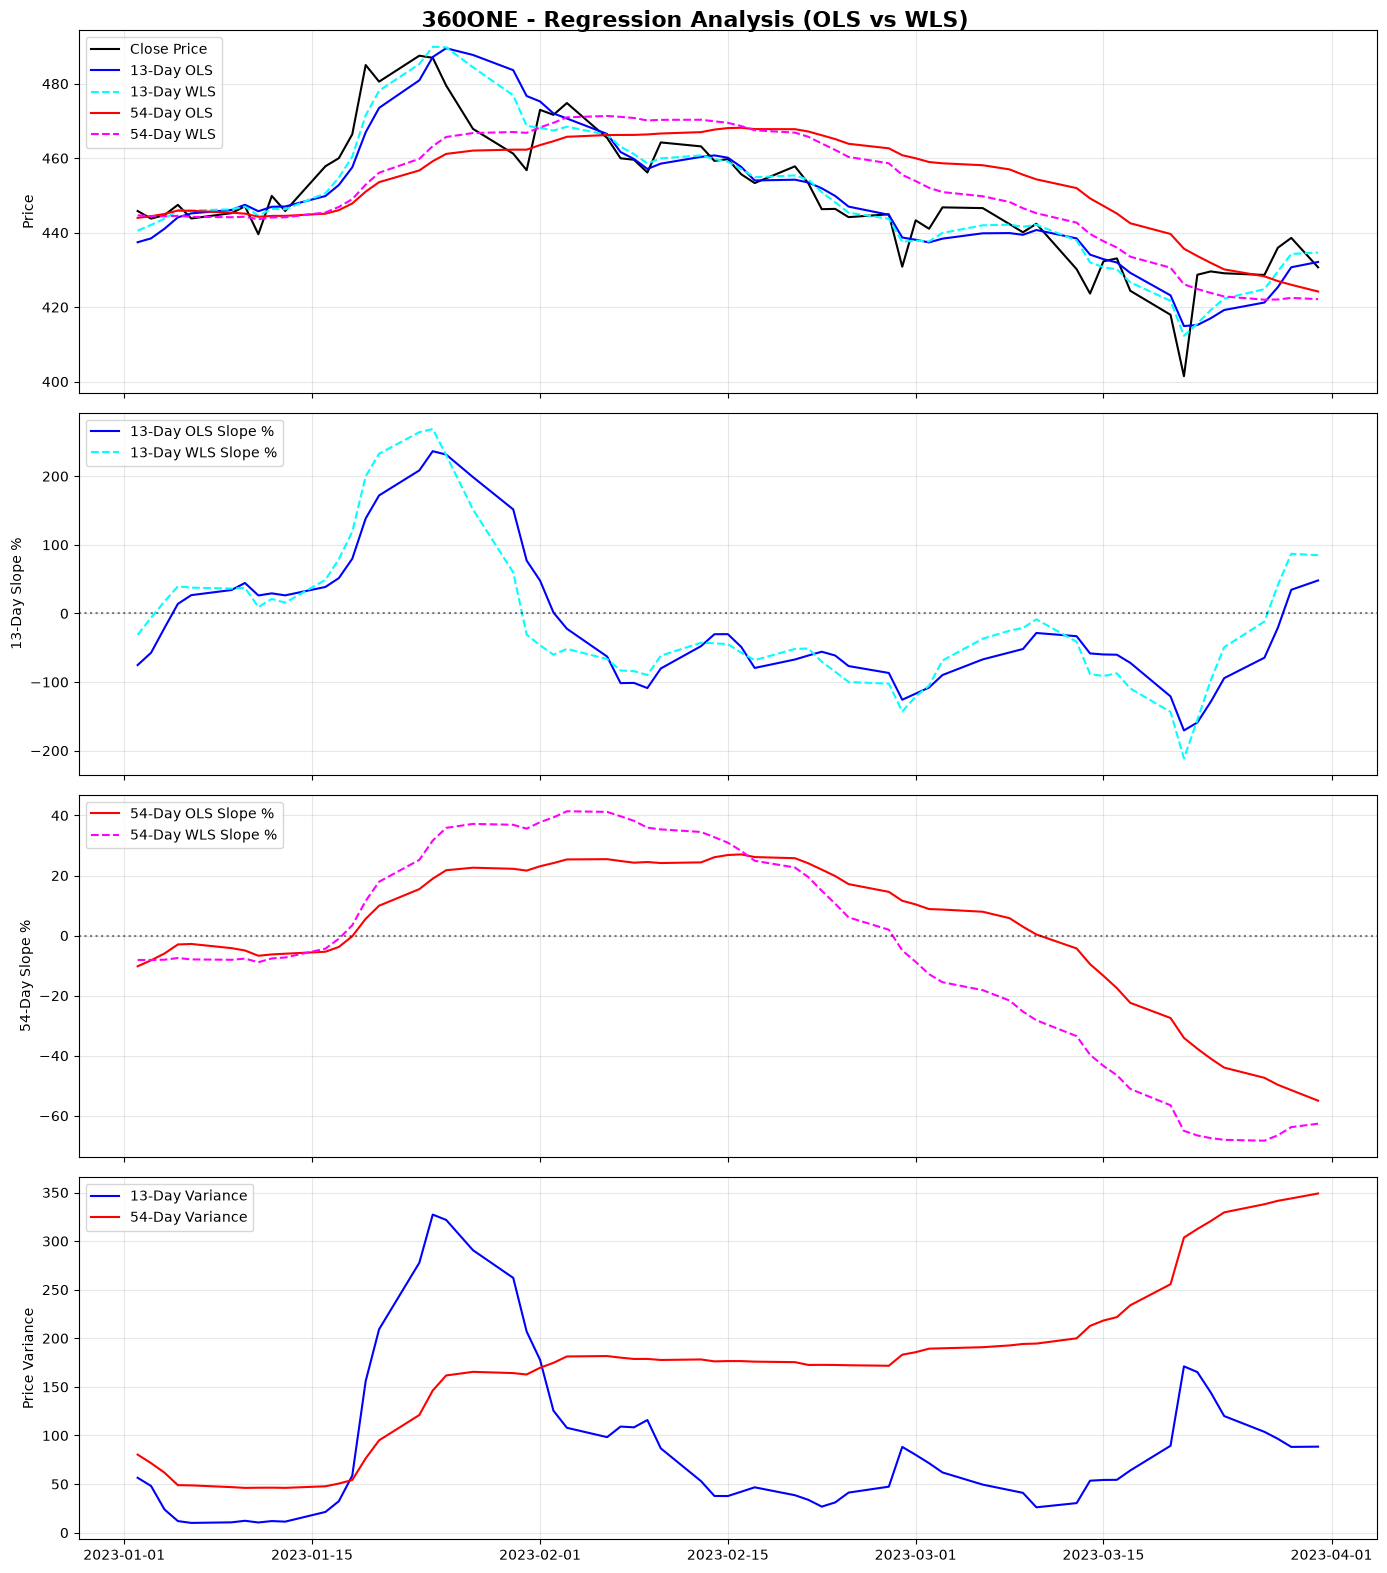

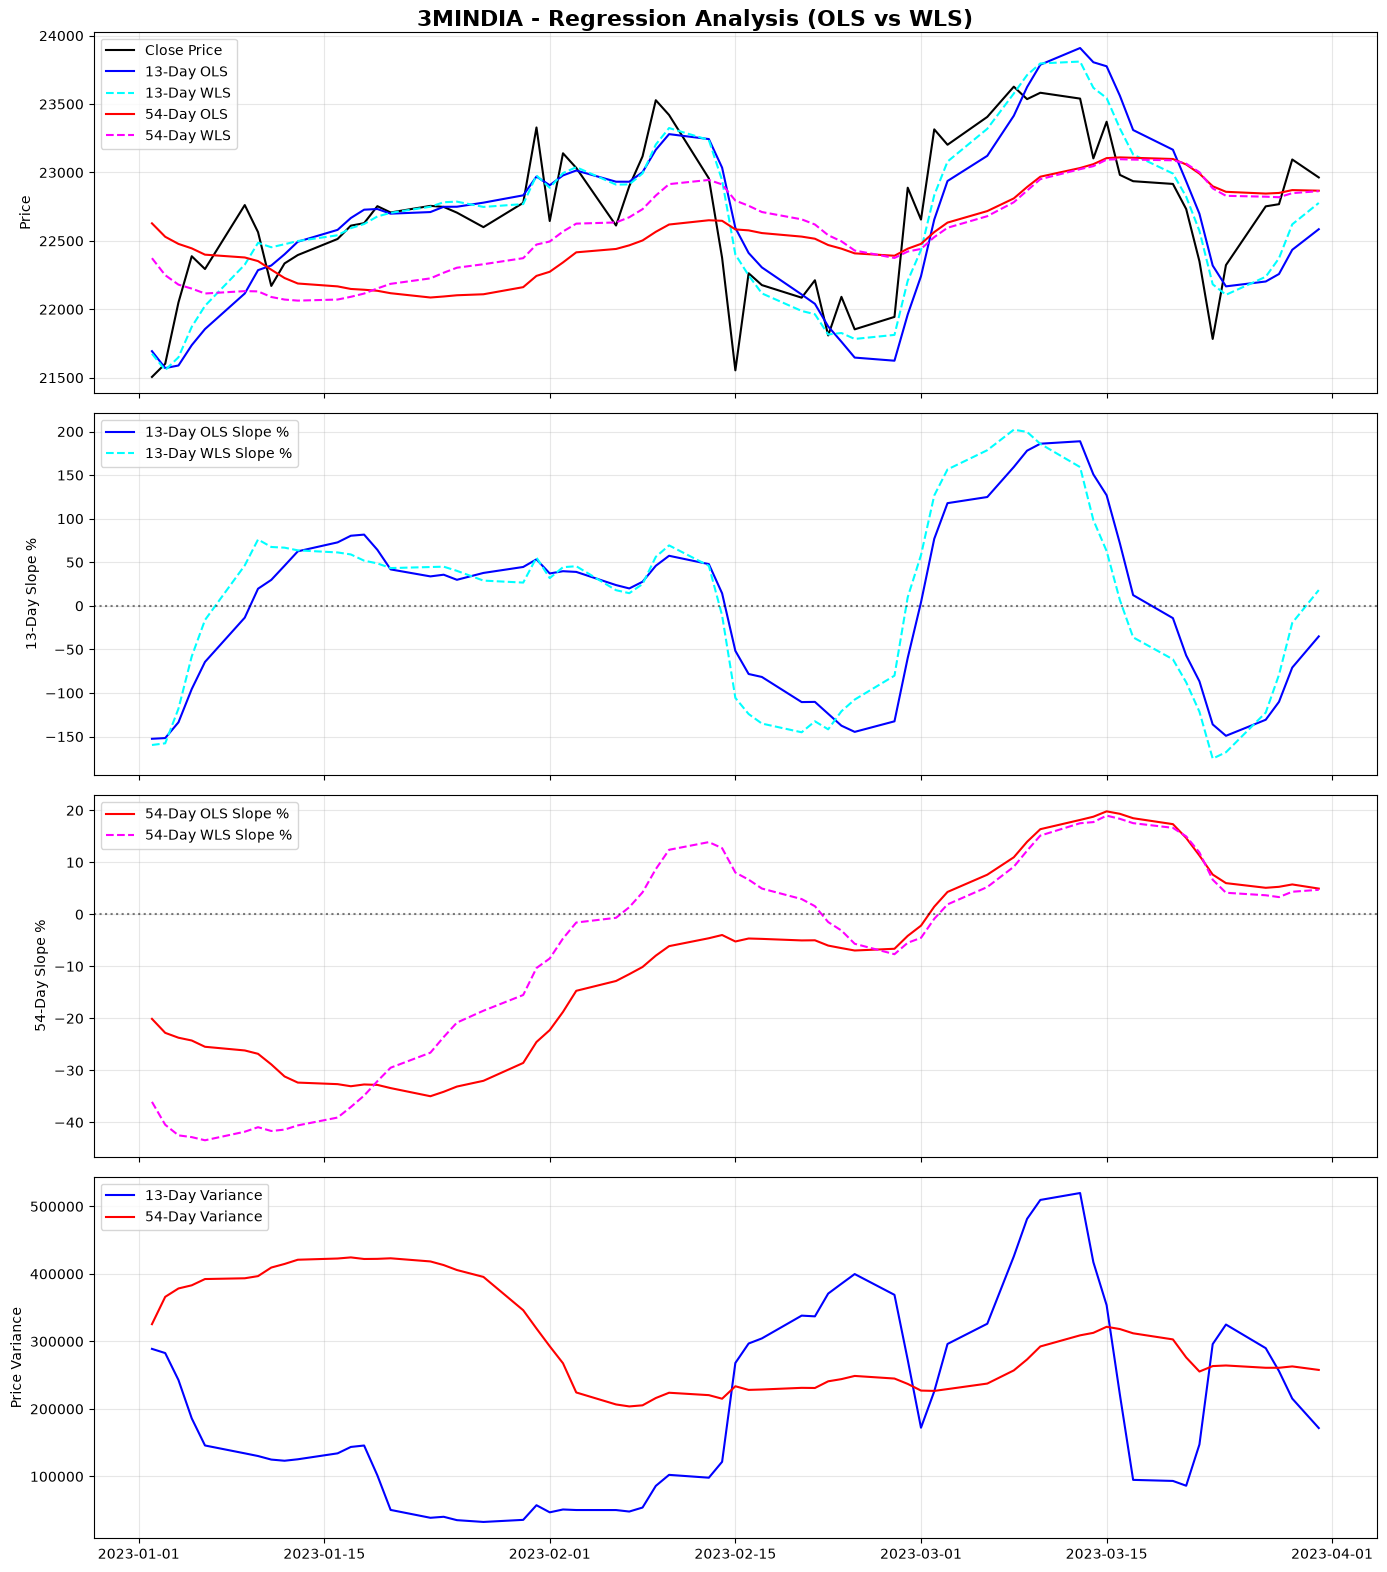

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # 1. Regression Lines & Slopes
    df['lr_13_ols'], df['slope_13_ols'] = calc_rolling_regression(df['Close'], LOOKBACK_SHORT, use_wls=False)
    df['lr_13_wls'], df['slope_13_wls'] = calc_rolling_regression(df['Close'], LOOKBACK_SHORT, use_wls=True)
    
    df['lr_54_ols'], df['slope_54_ols'] = calc_rolling_regression(df['Close'], LOOKBACK_LONG, use_wls=False)
    df['lr_54_wls'], df['slope_54_wls'] = calc_rolling_regression(df['Close'], LOOKBACK_LONG, use_wls=True)
    
    # 2. Variance
    df['var_13'] = df['Close'].rolling(LOOKBACK_SHORT).var()
    df['var_54'] = df['Close'].rolling(LOOKBACK_LONG).var()
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f"{stock_name} - Regression Analysis (OLS vs WLS)", fontsize=16, weight='bold')
    
    # Pane 1: Price and Regressions
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='black', label='Close Price', linewidth=1.5)
    axes[0].plot(plot_df['Date'], plot_df['lr_13_ols'], color='blue', linestyle='-', label='13-Day OLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_13_wls'], color='cyan', linestyle='--', label='13-Day WLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_54_ols'], color='red', linestyle='-', label='54-Day OLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_54_wls'], color='magenta', linestyle='--', label='54-Day WLS')
    axes[0].set_ylabel("Price")
    axes[0].legend(loc='upper left')
    axes[0].grid(alpha=0.3)
    
    # Pane 2: 13-Day Slope Comparison
    axes[1].plot(plot_df['Date'], plot_df['slope_13_ols'], color='blue', label='13-Day OLS Slope %')
    axes[1].plot(plot_df['Date'], plot_df['slope_13_wls'], color='cyan', linestyle='--', label='13-Day WLS Slope %')
    axes[1].axhline(0, color='black', linestyle=':', alpha=0.5)
    axes[1].set_ylabel("13-Day Slope %")
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)
    
    # Pane 3: 54-Day Slope Comparison
    axes[2].plot(plot_df['Date'], plot_df['slope_54_ols'], color='red', label='54-Day OLS Slope %')
    axes[2].plot(plot_df['Date'], plot_df['slope_54_wls'], color='magenta', linestyle='--', label='54-Day WLS Slope %')
    axes[2].axhline(0, color='black', linestyle=':', alpha=0.5)
    axes[2].set_ylabel("54-Day Slope %")
    axes[2].legend(loc='upper left')
    axes[2].grid(alpha=0.3)
    
    # Pane 4: Variance
    axes[3].plot(plot_df['Date'], plot_df['var_13'], color='blue', label='13-Day Variance')
    axes[3].plot(plot_df['Date'], plot_df['var_54'], color='red', label='54-Day Variance')
    axes[3].set_ylabel("Price Variance")
    axes[3].legend(loc='upper left')
    axes[3].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
